In [ ]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, StandardScaler, OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load Data

df = pd.read_csv('/content/drive/MyDrive/dataset_B_training.csv')
target_col = "h1n1_vaccine"

print("Data Loaded Successfully")
print("Shape:", df.shape)
df.head()


Data Loaded Successfully
Shape: (4756, 31)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,construction,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,real_estate,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0


In [ ]:
#  Univariate Analysis

print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())

missing_summary = (
    df.isnull().sum().reset_index()
    .rename(columns={'index':'Feature', 0:'MissingCount'})
)
missing_summary['MissingPct'] = (missing_summary['MissingCount'] / len(df)) * 100
missing_summary.sort_values('MissingPct', ascending=False).head(10)


Data types:
 respondent_id                    int64
h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
age_group                       object
education                       object
race                            object
sex                             object
income_poverty                  object
marital_status                  object
rent_or_own                     object
employment_

,Feature,MissingCount,MissingPct
29,employment_sector,2364,49.705635
14,health_insurance,1925,40.475189
22,income_poverty,712,14.970563
10,doctor_recc_h1n1,319,6.707317
24,rent_or_own,315,6.623213
25,employment_status,235,4.941127
23,marital_status,226,4.751892
19,education,224,4.709840
11,chronic_med_condition,161,3.385198
12,child_under_6_months,134,2.817494


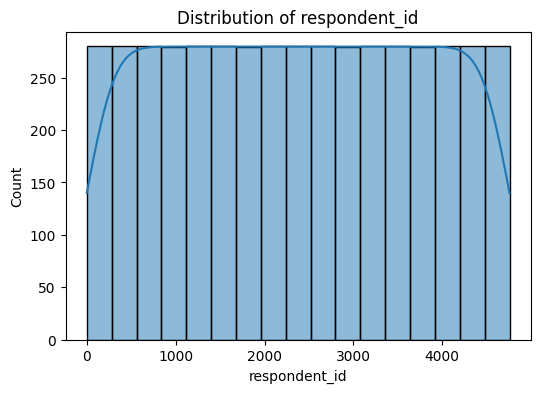

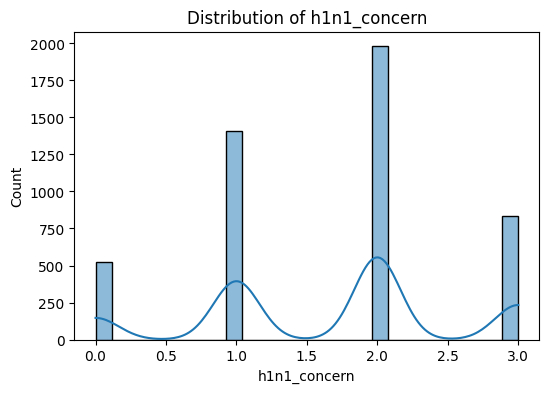

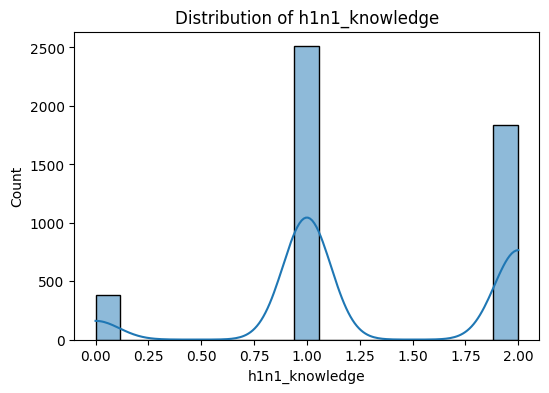

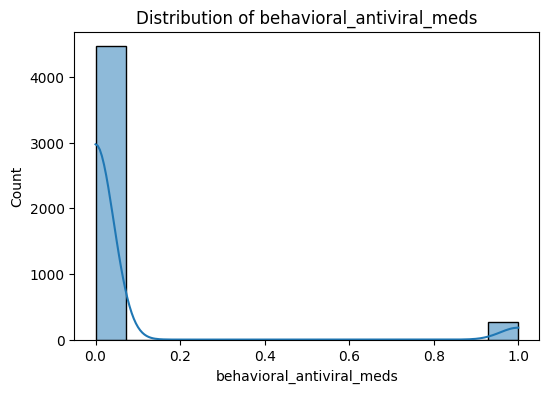

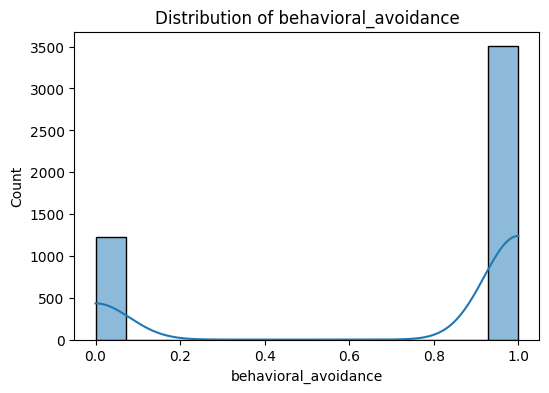

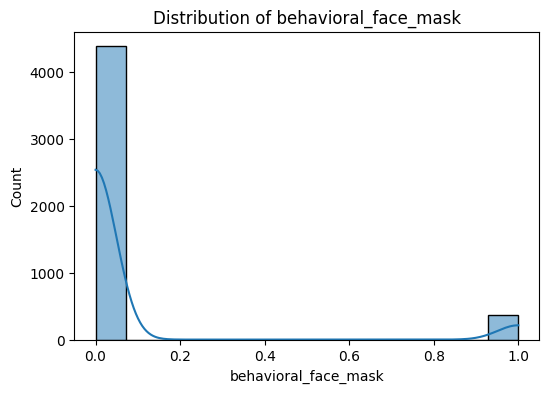

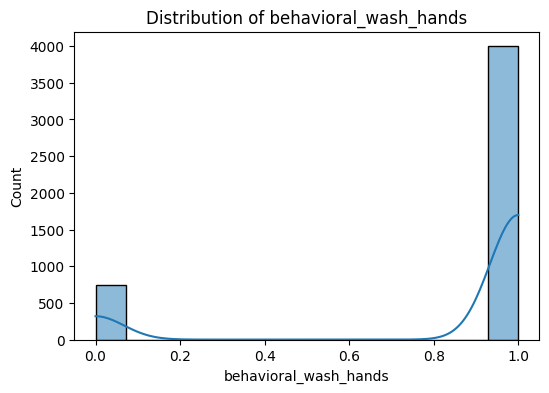

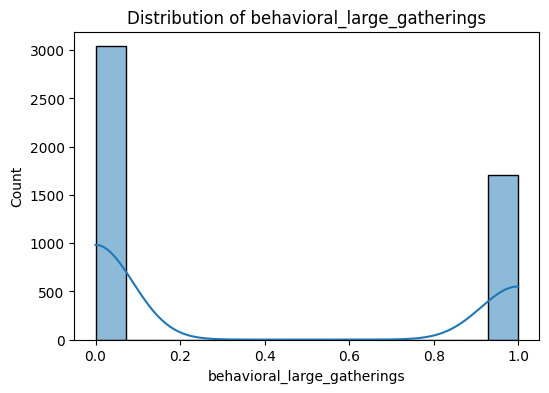

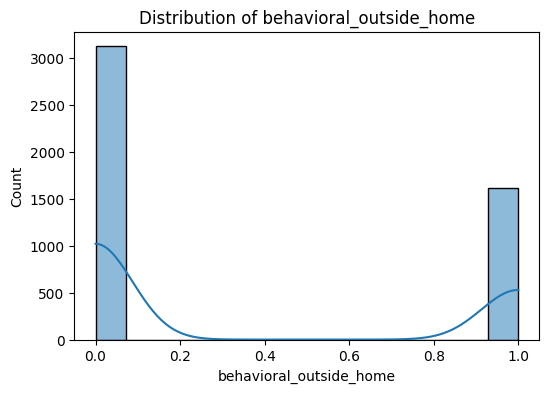

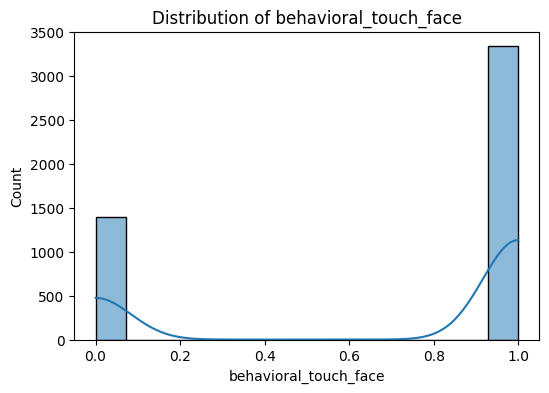

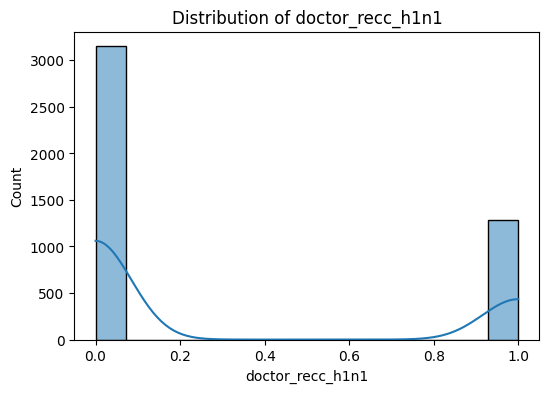

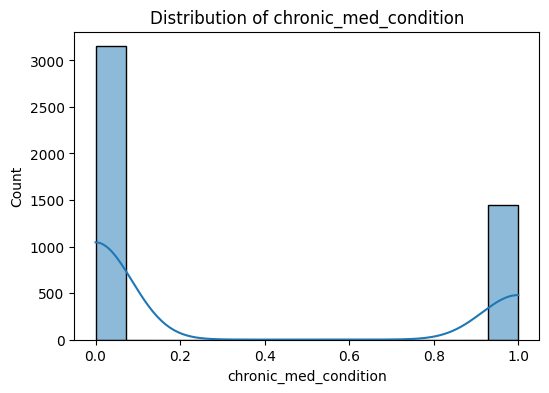

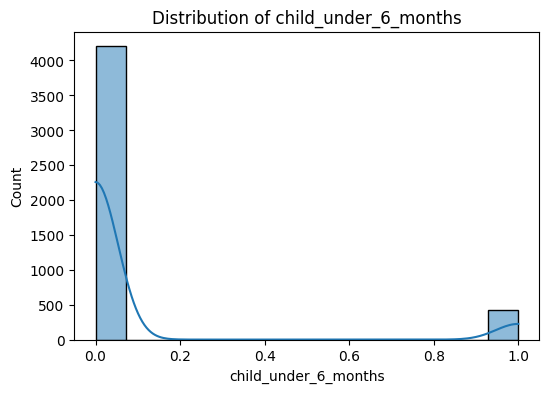

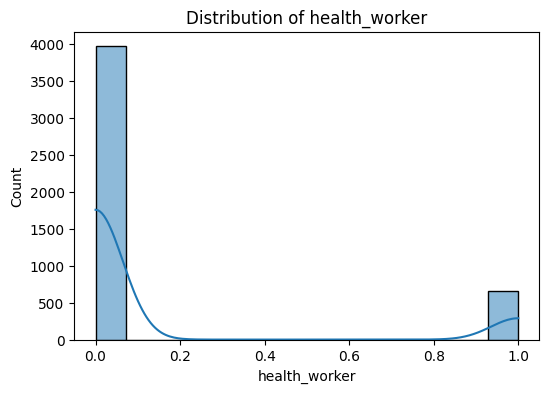

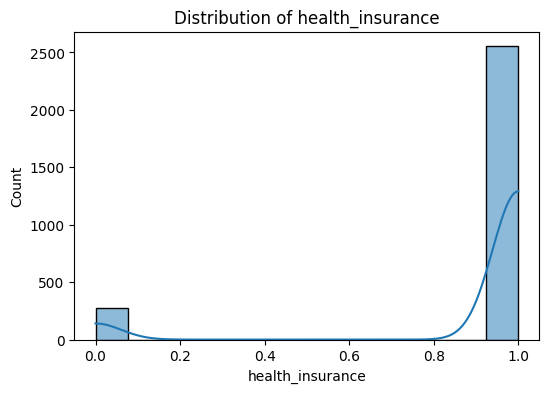

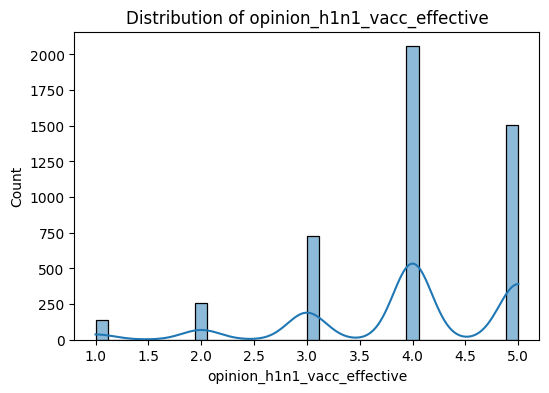

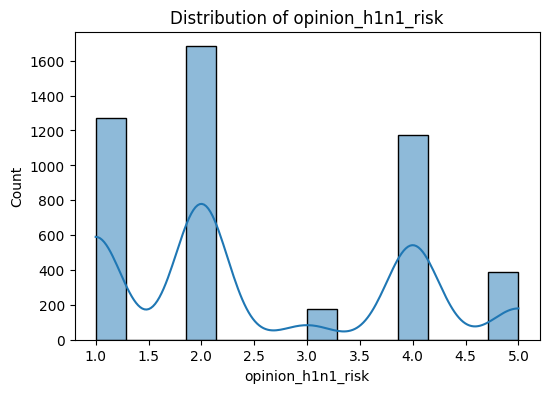

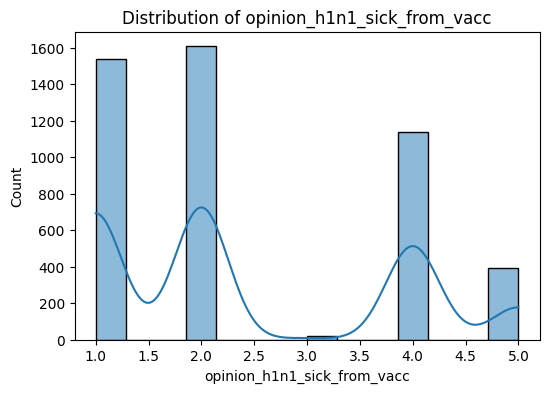

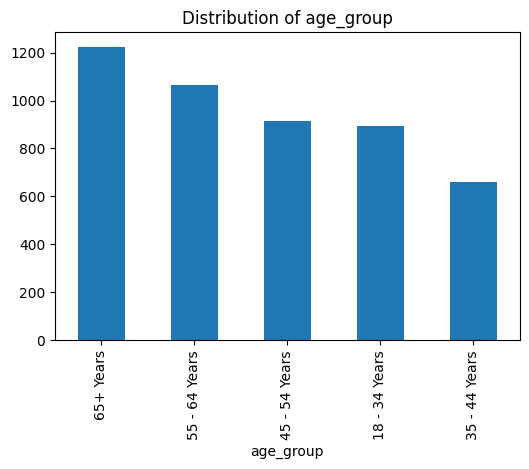

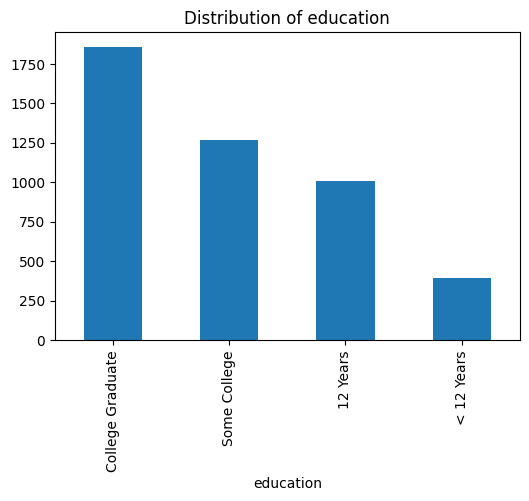

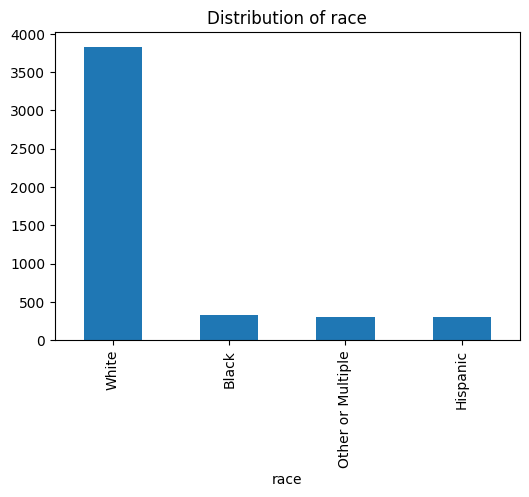

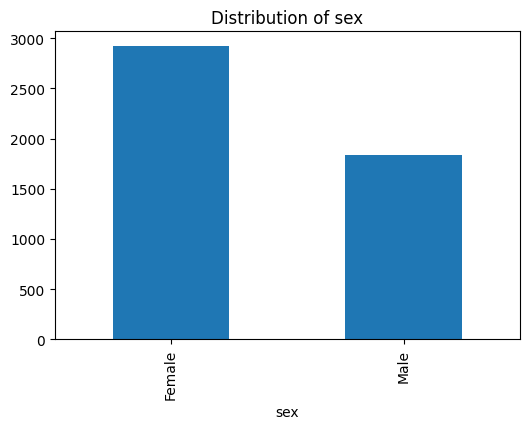

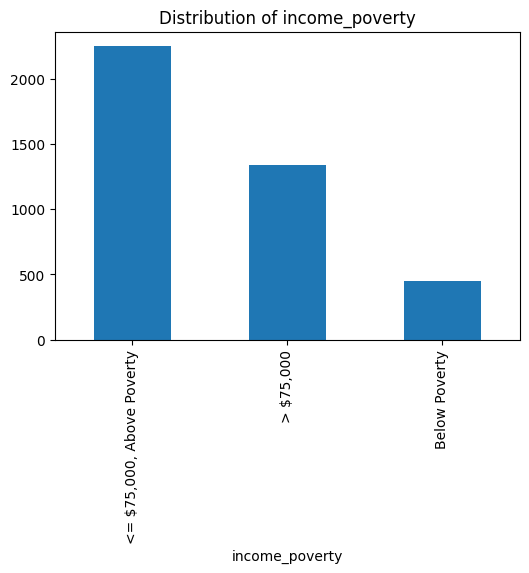

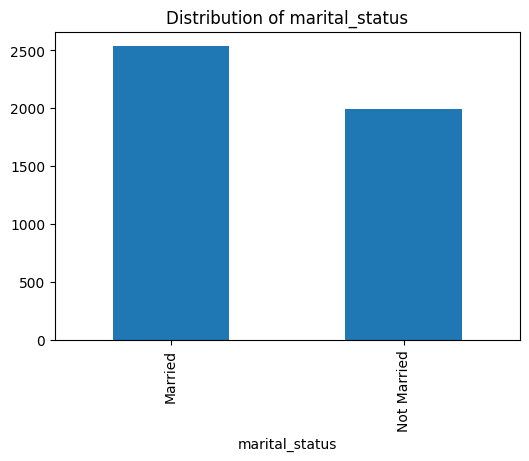

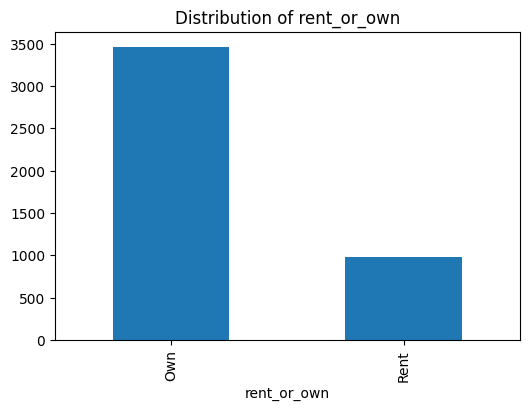

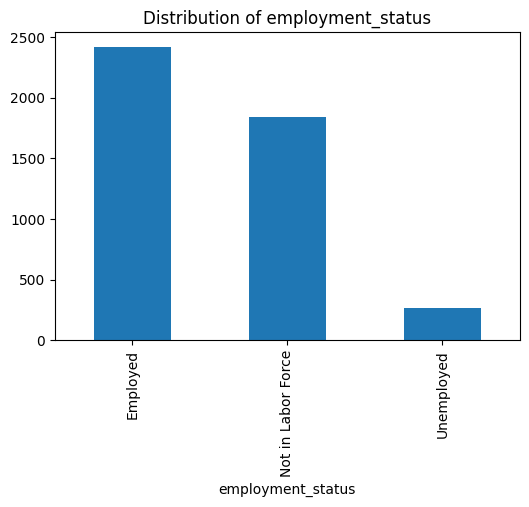

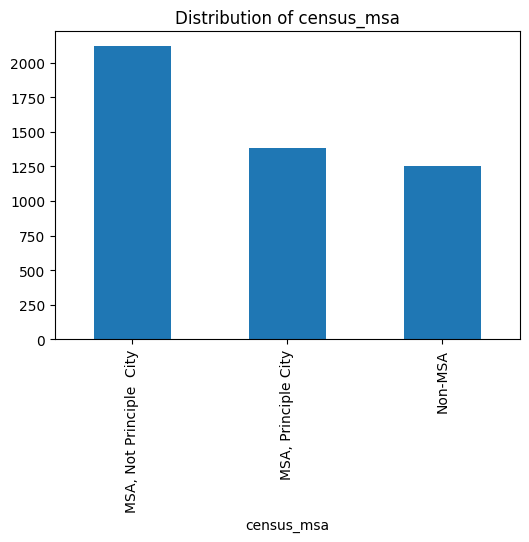

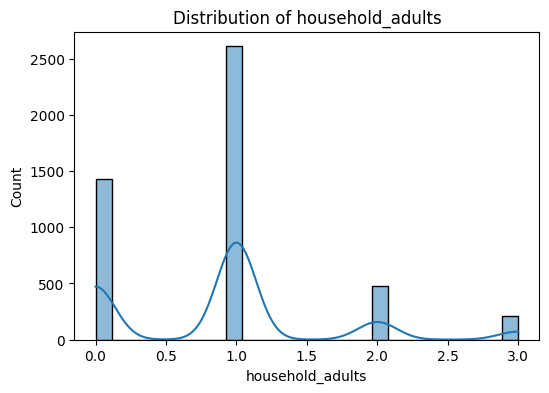

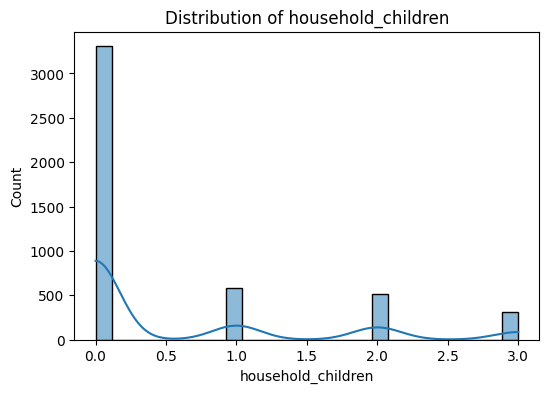

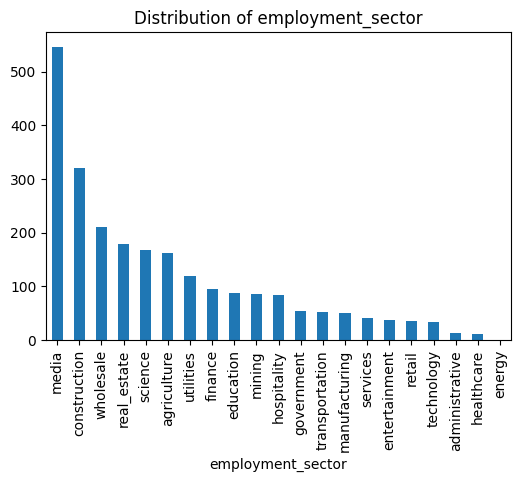

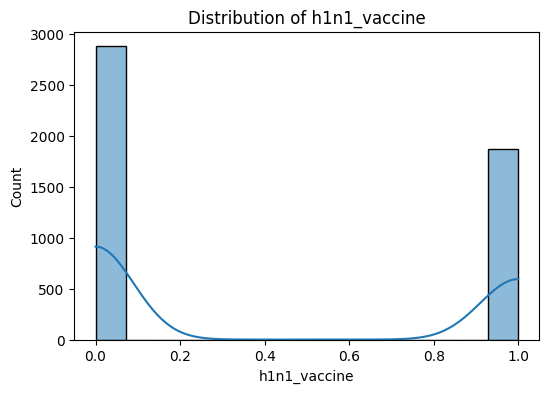

In [ ]:
#  Histograms and Bar plots
for col in df.columns:
    plt.figure(figsize=(6,4))
    if df[col].dtype in ["int64", "float64"]:
        sns.histplot(df[col], kde=True)
    else:
        df[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.show()

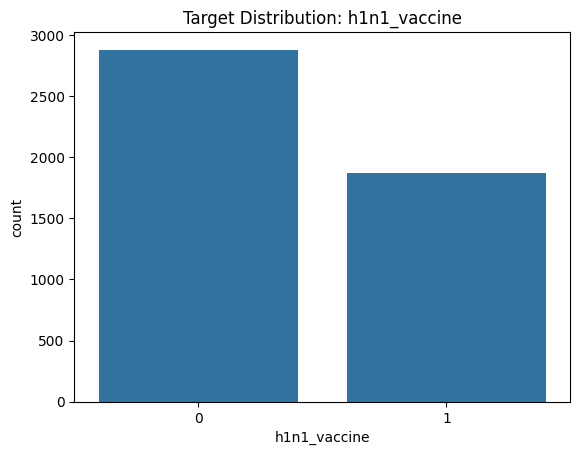

In [ ]:
# --- Target distribution ---
target_col = "h1n1_vaccine"
if target_col in df.columns:
    sns.countplot(x=target_col, data=df)
    plt.title("Target Distribution: h1n1_vaccine")
    plt.show()

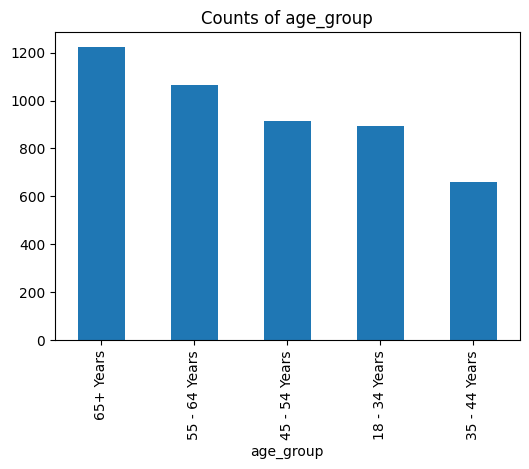

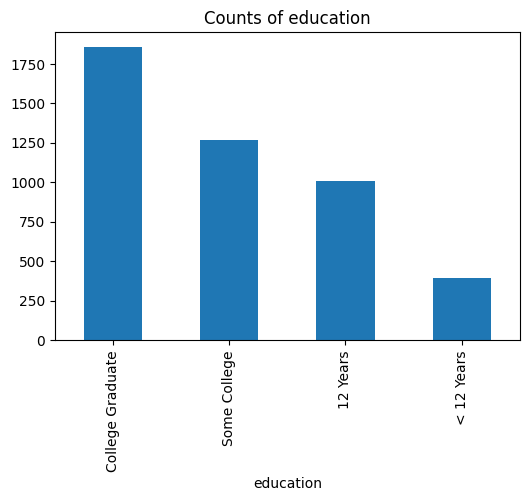

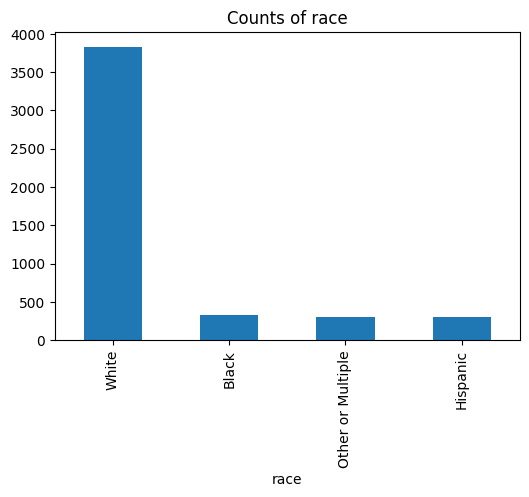

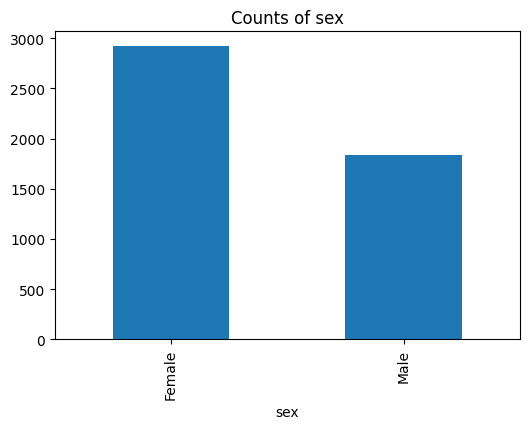

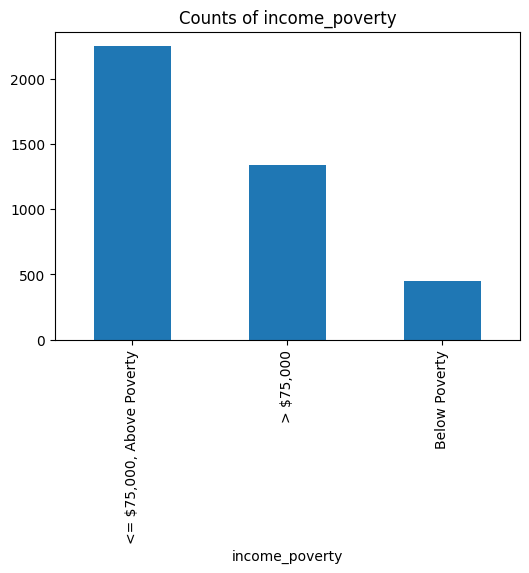

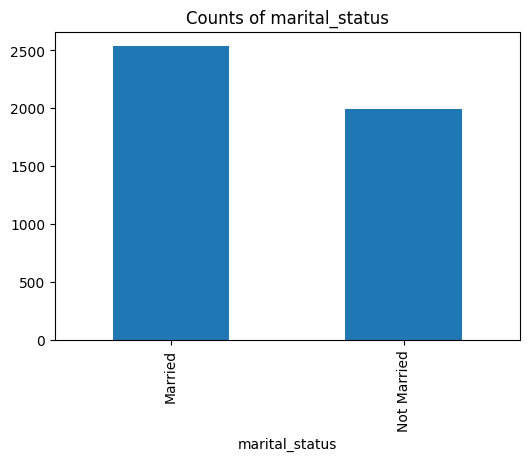

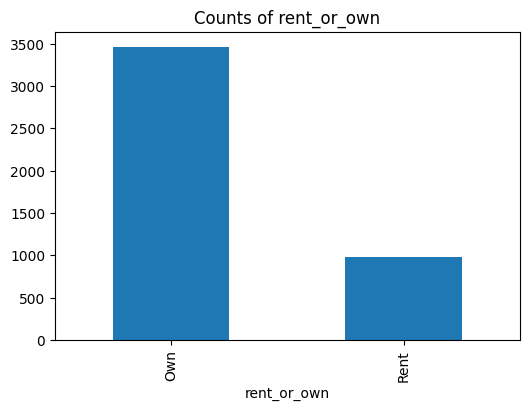

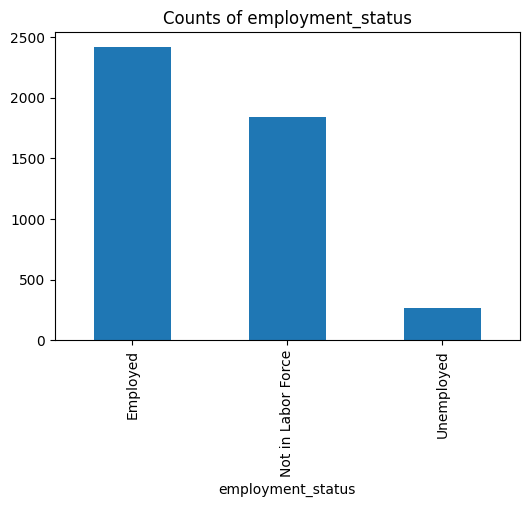

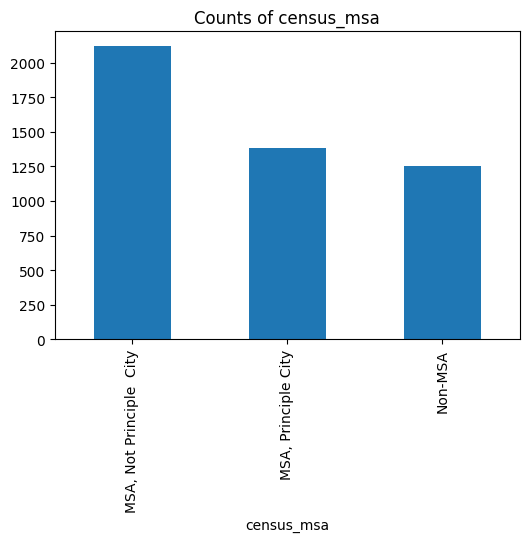

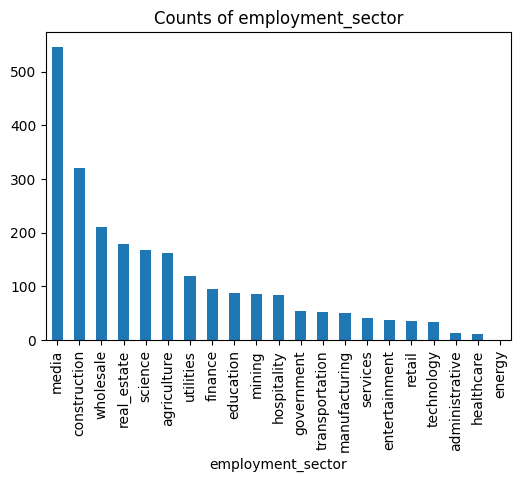

In [ ]:
# Categorical variable counts
cat_cols = df.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Counts of {col}")
    plt.show()